# (EX) PySpark example with linear regression model

This set of notes covers the estimation and prediction with a linear regression model, and the use of PySpark in order to parallelize and scale in computation.  In addition, the notes provide a brief commentary on privacy preserving machine learning models.

## Linear regression refresher

To fit a linear regression (without any penalty or regularization) can be done via the least-squares estimation:

$$\min_\beta~\ell(\beta) = \|\mathbf{y} - \mathbf{X} \beta \|_2^2,$$

The corresponding analytical solution can be found by setting the partial derivatives to zero:
$$\frac{\partial \ell(\beta)}{\partial \beta} \equiv 0 \qquad \Rightarrow \qquad \widehat{\beta} = (\mathbf{X}^\mathsf{T}\mathbf{X})^{-1} \mathbf{X}^\mathsf{T}\mathbf{y}.$$

*Why do we need to think about parallelization at all?*

Say we have $n$ data points, i.e. $(\mathbf{x}_i, y_i)_{i=1}^n$. Take a look at the dimension of the quantities of interest:
$$\mathbf{X} \in \mathbb{R}^{n \times (d+1)}, \mathbf{y} \in \mathbb{R}^n.$$

The major computations involve three operations:  
1. Multiplication: $\mathbf{X}^\mathsf{T}\mathbf{X} = \sum_{i=1}^n \mathbf{x}_i \mathbf{x}_i^\mathsf{T},$
2. Multiplication: $\mathbf{X}^\mathsf{T}\mathbf{y} = \sum_{i=1}^n \mathbf{x_i} y_i,$
3. Inversion of matrix: $(\mathbf{X}^\mathsf{T}\mathbf{X})^{-1} \mathbf{X}^\mathsf{T}\mathbf{y}.$

*Rationale:*  
- In the case where $n$ is extremely large, the multiplication and summation, steps (1) and (2), are slow.
- Since the inversion of matrix is driven by the size of $\mathbf{X}^\mathsf{T}\mathbf{X}$, which is typically a relatively small $(d+1) \times (d+1)$ matrix.  Step (3) is relatively cheap in terms of computation.


## Coding component with the diamonds dataset as an example

In [ ]:
# You typically do not need this

import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-11.0.2"
os.environ["SPARK_HOME"] = r"C:\Program Files\Spark\spark-3.5.5-bin-hadoop3"

import findspark
findspark.init()

### Diamonds dataset

In [1]:
import seaborn as sns
diam = sns.load_dataset('diamonds', cache=True, data_home='dataset/')

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

# reading data
diamonds = (
    spark.read.format('csv')
    .options(header='true', inferSchema='true')
    .load('dataset/diamonds.csv')
    .cache()
)

In [3]:
diamonds.take(5)

[Row(carat=0.23, cut='Ideal', color='E', clarity='SI2', depth=61.5, table=55.0, price=326, x=3.95, y=3.98, z=2.43),
 Row(carat=0.21, cut='Premium', color='E', clarity='SI1', depth=59.8, table=61.0, price=326, x=3.89, y=3.84, z=2.31),
 Row(carat=0.23, cut='Good', color='E', clarity='VS1', depth=56.9, table=65.0, price=327, x=4.05, y=4.07, z=2.31),
 Row(carat=0.29, cut='Premium', color='I', clarity='VS2', depth=62.4, table=58.0, price=334, x=4.2, y=4.23, z=2.63),
 Row(carat=0.31, cut='Good', color='J', clarity='SI2', depth=63.3, table=58.0, price=335, x=4.34, y=4.35, z=2.75)]

In [4]:
# subsetting dataset for analysis
df = (
    diamonds
    .where(diamonds['price'] > 1000)
    .select(['cut', 'color', 'carat', 'clarity', 'price'])
)

In [5]:
df.show(5)

+---------+-----+-----+-------+-----+
|      cut|color|carat|clarity|price|
+---------+-----+-----+-------+-----+
|    Ideal|    E|  0.7|    SI1| 2757|
|     Fair|    E| 0.86|    SI2| 2757|
|    Ideal|    G|  0.7|    VS2| 2757|
|Very Good|    E| 0.71|    VS2| 2759|
|Very Good|    G| 0.78|    SI2| 2759|
+---------+-----+-----+-------+-----+
only showing top 5 rows


In [6]:
row = diamonds.take(1)

In [7]:
# assigning predictors and response
predictors = ['cut', 'color', 'carat', 'clarity']
categorical = set(['cut', 'color', 'clarity'])
response = 'price'

### Map functions explained - collecting necessary information


The individual (row) component within the sum can be calculated as:

\begin{align}
    \mathbf{x}_i \mathbf{x}_i^\mathsf{T} =
    \begin{pmatrix}
    x_{i1}^2 & x_{i1} x_{i2} & \ldots & x_{i1} x_{id} \\
    \vdots & \ddots & \ldots & \vdots \\
    x_{id}x_{i1} & x_{id}x_{i2} & \ldots & x_{id}^2
    \end{pmatrix},
    \qquad
    \mathbf{x}_i y_i =
    \begin{pmatrix}
    x_{i1}y_i \\ x_{i2} y_i \\ \vdots \\ x_{id} y_i
    \end{pmatrix}.
\end{align}

To keep track of which value corresponds to each column, the `yield` function keeps a record of the column names as keys.

In [19]:
# map functions for step (1) and (2)
def xtx_map(row):
    row = row.asDict()
    for i in predictors:
        (ki, vi) = (i, row[i]) if i not in categorical else (i+"_"+row[i], 1.0)
        for j in predictors:
            (kj, vj) = (j, row[j]) if j not in categorical else (j+"_"+row[j], 1.0)
            yield ((ki, kj), vi * vj) # tells which row and column we are computing, product

def xty_map(row):
    row = row.asDict()
    for j in predictors:
        (kj, vj) = (j, row[j]) if j not in categorical else (j+"_"+row[j], 1.0)
        yield (kj, vj * row[response])

In [23]:
row = df.take(1)
row[0]

Row(cut='Ideal', color='E', carat=0.7, clarity='SI1', price=2757)

In [24]:
# inspecting the result from applying xty_map to one row
[a for a in xty_map(row[0])]

[('cut_Ideal', 2757.0),
 ('color_E', 2757.0),
 ('carat', 1929.8999999999999),
 ('clarity_SI1', 2757.0)]

In [25]:
# inspecting the result from applying xtx_map to one row
[a for a in xtx_map(row[0])]

[(('cut_Ideal', 'cut_Ideal'), 1.0),
 (('cut_Ideal', 'color_E'), 1.0),
 (('cut_Ideal', 'carat'), 0.7),
 (('cut_Ideal', 'clarity_SI1'), 1.0),
 (('color_E', 'cut_Ideal'), 1.0),
 (('color_E', 'color_E'), 1.0),
 (('color_E', 'carat'), 0.7),
 (('color_E', 'clarity_SI1'), 1.0),
 (('carat', 'cut_Ideal'), 0.7),
 (('carat', 'color_E'), 0.7),
 (('carat', 'carat'), 0.48999999999999994),
 (('carat', 'clarity_SI1'), 0.7),
 (('clarity_SI1', 'cut_Ideal'), 1.0),
 (('clarity_SI1', 'color_E'), 1.0),
 (('clarity_SI1', 'carat'), 0.7),
 (('clarity_SI1', 'clarity_SI1'), 1.0)]

In [26]:
xtx_data = (df.rdd
            .flatMap(xtx_map)
            .reduceByKey(lambda a, b: a+b) # have to reduce by something - this matches and adds ones with the same key
            .collect()
           )

In [27]:
xty_data = (df.rdd
            .flatMap(xty_map)
            .reduceByKey(lambda a, b: a+b)
            .collect()
           )

In [28]:
xtx_data

[(('cut_Ideal', 'cut_Ideal'), 14700.0),
 (('cut_Ideal', 'color_E'), 2539.0),
 (('cut_Ideal', 'carat'), 12862.460000000412),
 (('cut_Ideal', 'clarity_SI1'), 3129.0),
 (('color_E', 'cut_Ideal'), 2539.0),
 (('color_E', 'color_E'), 6747.0),
 (('color_E', 'carat'), 5443.270000000176),
 (('color_E', 'clarity_SI1'), 1721.0),
 (('carat', 'cut_Ideal'), 12862.460000000412),
 (('carat', 'color_E'), 5443.270000000176),
 (('carat', 'carat'), 44793.20149999397),
 (('carat', 'clarity_SI1'), 10011.490000000455),
 (('clarity_SI1', 'cut_Ideal'), 3129.0),
 (('clarity_SI1', 'color_E'), 1721.0),
 (('clarity_SI1', 'carat'), 10011.490000000455),
 (('clarity_SI1', 'clarity_SI1'), 9978.0),
 (('cut_Fair', 'cut_Fair'), 1499.0),
 (('cut_Fair', 'color_E'), 199.0),
 (('cut_Fair', 'carat'), 1637.2600000000039),
 (('cut_Fair', 'clarity_SI2'), 457.0),
 (('color_E', 'cut_Fair'), 199.0),
 (('color_E', 'clarity_SI2'), 1457.0),
 (('carat', 'cut_Fair'), 1637.2600000000039),
 (('carat', 'clarity_SI2'), 9505.900000000218),
 

In [29]:
xty_data

[('cut_Ideal', 69491685.0),
 ('color_E', 27913897.0),
 ('carat', 259765355.250002),
 ('clarity_SI1', 50141077.0),
 ('cut_Fair', 6931384.0),
 ('clarity_SI2', 45876510.0),
 ('color_G', 42841867.0),
 ('clarity_VS2', 45536589.0),
 ('cut_Very Good', 45996850.0),
 ('cut_Good', 18558296.0),
 ('color_F', 33724244.0),
 ('clarity_VS1', 29642262.0),
 ('cut_Premium', 60868420.0),
 ('color_H', 35873113.0),
 ('color_D', 19990260.0),
 ('color_I', 26838093.0),
 ('clarity_VVS2', 15250346.0),
 ('clarity_VVS1', 8043137.0),
 ('color_J', 14665161.0),
 ('clarity_I1', 2860076.0),
 ('clarity_IF', 4496638.0)]

### Indexing - keeping track of which columns the values belong to

Individual calculations from distributed resources will return in **any** order, therefore, calculating the index of each column key is necessary.

In [30]:
index = dict(zip([r[0] for r in xty_data], range(len(xty_data))))
p = len(index)

index

{'cut_Ideal': 0,
 'color_E': 1,
 'carat': 2,
 'clarity_SI1': 3,
 'cut_Fair': 4,
 'clarity_SI2': 5,
 'color_G': 6,
 'clarity_VS2': 7,
 'cut_Very Good': 8,
 'cut_Good': 9,
 'color_F': 10,
 'clarity_VS1': 11,
 'cut_Premium': 12,
 'color_H': 13,
 'color_D': 14,
 'color_I': 15,
 'clarity_VVS2': 16,
 'clarity_VVS1': 17,
 'color_J': 18,
 'clarity_I1': 19,
 'clarity_IF': 20}

In [31]:
# arrange the individual elements back into matrices
import numpy as np

XTY = np.zeros((p, 1))
for (k, v) in xty_data:
  XTY[index[k]] = v

XTX = np.zeros((p,p))
for ((k1,k2),v) in xtx_data:
  XTX[index[k1], index[k2]] = v

In [32]:
XTX.shape, XTY.shape

((21, 21), (21, 1))

### Estimation of $\beta$

In [33]:
beta = np.linalg.solve(XTX, XTY)

In [34]:
beta  # beta hat

array([[ 9.07669569e+06],
       [ 2.51339285e+07],
       [ 9.80568171e+03],
       [-3.42145650e+07],
       [ 9.07573816e+06],
       [-3.42156039e+07],
       [ 2.51334735e+07],
       [-3.42137872e+07],
       [ 9.07649806e+06],
       [ 9.07623993e+06],
       [ 2.51338035e+07],
       [-3.42134031e+07],
       [ 9.07643779e+06],
       [ 2.51327973e+07],
       [ 2.51341431e+07],
       [ 2.51321632e+07],
       [-3.42127670e+07],
       [-3.42125306e+07],
       [ 2.51311762e+07],
       [-3.42185029e+07],
       [-3.42119765e+07]])

## Prediction with $\widehat{\beta}$

In [35]:
# digression: some handy shape-conforming functions in numpy
beta.shape
np.squeeze(beta).shape
np.atleast_3d(beta).shape

(21, 1, 1)

In [36]:
## a new row contains a set of predictors
def predict(row):
    row = row.asDict()
    pred = 0.0
    for j in predictors:
        (kj, vj) = (j, row[j]) if j not in categorical else (j+"_"+row[j], 1.0)
        pred += vj * beta[index[kj], 0]
    return float(pred)



In [37]:
from pyspark.sql.functions import mean

# calculating error
rmse = np.sqrt(
    df.rdd
    .map(lambda row: (row[response], predict(row)))
    .map(lambda y: (y[1] - y[0])**2)
    .mean()
)

In [38]:
rmse = np.sqrt(
    df.rdd
    .map(lambda row: (row[response] - predict(row))**2)
    .mean()
)

In [39]:
rmse

np.float64(1177.111966961308)

## User-defined functions (UDF)

In many scenarios, storing the calculations in a new column of the RDD dataframe is advantageous. In a similar way, the computations are not performed until you try to retrieve the results, e.g. via "collect".

User-defined functions allow for a clean way to achieve this purpose.

- makes the function readable by pyspark
- need to specify what goes in and out. here, define that it returns a float


In [40]:
from pyspark.sql.functions import udf, struct
from pyspark.sql.types import FloatType

predict_udf = udf(predict, FloatType())

df = df.withColumn("pred", predict_udf(struct(predictors)))


In [41]:
df = df.withColumn("resid", df['pred'] - df['price'])

In [42]:
df.printSchema() # still have not computed anything

root
 |-- cut: string (nullable = true)
 |-- color: string (nullable = true)
 |-- carat: double (nullable = true)
 |-- clarity: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- pred: float (nullable = true)
 |-- resid: double (nullable = true)



<Axes: ylabel='Count'>

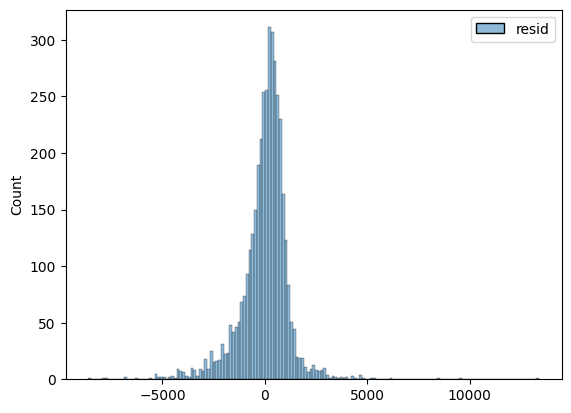

In [43]:
sns.histplot(df.sample(False, 0.1).select('resid').toPandas()) # this is where the collection (calculation) happens